## ======= Análisis de Datos =======

En esta notebook vamos a ver ejemplos de como utilizar la librería Pandas para el análisis de datos. Veremos como es mucho mejor que utilizar una planilla de cálculo convencional (sin embargo estaremos muy lejos de explorar todas sus capacidades). Además, al mismo tiempo, continuaremos mejorando nuestra interacción con Python y la (buena) escritura de código. Notemos que Python es el lenguaje más utilizado del mundo y Pandas una de las librerías pilares en _Data Science_.

La idea es que en un futuro, puedan _cambiar el chip de las planillas de cálculo_ por Pandas o, en todo caso, que las planillas sean de caracter accessorio a un trabajo fundado en Pandas. Esto sin duda los pondrá en un lugar diferencial respecto de los que usan planillas de cálculo.

### 0. (LEER BIEN) Parte del código de esta notebook está en Markdown porque lo estoy escribiendo localmente. Entonces, por ejemplo, no necesito montar mi unidad de Drive. Uds lo van a escribir en una celda de Python en su Colab. _Una vez más_: lo van a tener que copiar y pegar en una celda de Python (código) en su Colab.

#### 1. Montar nuestra unidad de Google Drive

Esto es útil porque Colab leerá nuestros archivos directo desde nuestra unidad. SIEMPRE DEBEMOS MONTAR TODO NUESTRO DRIVE COMO PRIMER PASO.

```
from google.colab import drive
drive.mount('/content/drive')
```

Por defecto todo el contenido de nuesta unidad estará en la ruta `/content/drive/MyDrive`

#### 2. Como vamos a leer archivos de planillas de cálculo, _es posible_ que debamos instalar una librería de Python que los lea. Como estamos en Colab, para ejecutar una instalación que _va por arriba_ de Colab, necesitamos anteponer un "!". 

ACTUALIZACIÓN: En la última versión de Colab que usamos, recibimos un mensaje de que la librería `openpyxl` ya estaba instalada. Por lo que, si las cosas se mantienen así, podemos saltearnos este paso.

#### Para archivos .xlsx: 

```!pip install openpyxl```

#### Para archivos .ods: 

```!pip install odfpy```

#### 3.(En una celda nueva) Ahora ya podemos pasar a DataFrame nuestro archivo de planilla de cálculo con Pandas. Recordar escribir `import pandas as pd` antes que nada. Volvemos a la observación previa: 

- Si lo tenemos _suelto_ en nuestra unidad, cuando usemos `pd.read_excel` (en el caso de ser un .xlsx), le pasamos la _ruta completa al archivo_

    ```df = pd.read_excel('/content/drive/MyDrive/mi_archivo.xlsx')```

- Si lo tenemos en una carpeta específica donde tenemos muchos archivos y vamos a requerir leer varios de esos archivos en diferentes instancias (no es nuestro caso), podemos indicarle a Python cuál va a ser nuestro directorio de trabajo, y así evitar tener que copiar la ruta completa de cada archivo cada vez. Por ejemplo, supongamos que tenemos una carpeta llamada `Test_Folder` en nuestra unidad.

```
import os
os.chdir('/content/drive/MyDrive/Test_Folder')
os.getcwd()
```

La última línea es para que nos muestre el directorio de trabajo como salida de la celda. Si optamos por esta segunda opción, ya no tendremos que escribir toda la ruta a nuestros archivos, simplemente pondríamos, para un archivo que se encuentra en Test_Folder,

```df = pd.read_excel('mi_archivo.xlsx')```

Recordar escribir al final de la celda `df` para que nos muestre para que Colab nos muestre el DataFrame. Esta forma de visualizarlo es mejor que un `print`, sólo hay que tener en cuenta que debemos colocar el DataFrame como última línea.

MUCHO CUIDADO con los nombres de los archivos. Evitar espacios es lo ideal. Como estamos usando Python, podemos implementar _snakecase_.

In [1]:
import pandas as pd

df = pd.read_excel('clase_algoritmos_intro_notas.xlsx')

df

,Estudiantes,Edad,Calificación
0,Sánchez María,35,10
1,Rodríguez Juan,24,1
2,Gómez Ana,22,8
3,Fernández Pedro,43,7
4,López Laura,58,3
5,Martínez Carlos,29,1
6,Díaz Sofía,47,8
7,Pérez Martín,33,10
8,García Florencia,56,6
9,Romero Diego,37,9


#### 4. Una herramienta muy útil para visualizar datos son los *histogramas*. En clase vimos como las planillas de cálculo de Google o Excel no soportan intervalos personalizados (bins) para las frecuencias. Sin embargo, con Python y Pandas podemos hacerlo de forma muy sencilla

<Axes: >

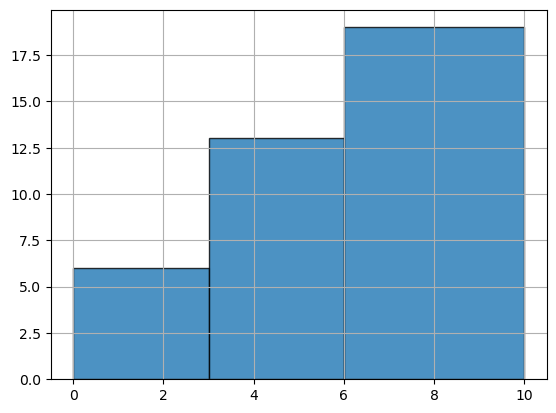

In [2]:
# Bins (intervalos) personalizados

# Cuando pasamos una lista de bordes a bins (como [0, 3, 5, 10]), Matplotlib (y Pandas, que usa Matplotlib) crea los intervalos de la siguiente manera:

# Todos los intervalos, excepto el último, son cerrados por la izquierda y abiertos por la derecha:
# [inicio, fin) 

# El último intervalo es cerrado en ambos extremos:
# [inicio, fin] 


# situación y tamaño de los bins

bins_personalizados = [0, 3, 6 , 10]


df["Calificación"].hist(
    bins = bins_personalizados,
    edgecolor='black',
    alpha=0.8 # transparencia de las barras
)


#### En este [enlace](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) pordemo ver la documentación del método `.hist()` 

#### También podemos ver numéricamente las frecuencias con `.value_counts()`. Por default no nos ordena los datos de forma creciente o decreciente, por eso le aplicamos al final `.sort_index()`.

In [3]:
frecuencias_notas = df["Calificación"].value_counts().sort_index()

frecuencias_notas

# print(type(frecuencias_notas))

Calificación
1     4
2     2
3     5
4     2
5     6
6     3
7     4
8     3
9     5
10    4
Name: count, dtype: int64

In [4]:
# siempre podemos convertir en Data Frame una Serie
df_frecuencias_notas = pd.DataFrame(frecuencias_notas)

df_frecuencias_notas

,count
Calificación,
1,4
2,2
3,5
4,2
5,6
6,3
7,4
8,3
9,5


#### Renombrar y ordenar columnas

A veces las columnas del `.xlsx` vienen con nombres que no deseamos, podemos cambiarlos fácilmente con el método `.rename()`. La mayoría de los métodos en Pandas devuelven _una copia_ del df original con el método aplicado. Si queremos sustituir el df original debemos utilixar `inplace = True` o asignar a la misma variable que contiene nuestro Data Frame la copia que devuelve el método.

In [5]:
df.rename(columns={
    'Estudiantes': 'Estudiante',
    'Calificación': 'Nota 1'
}, inplace = True)

# df = df.rename(columns={'Estudiantes': 'Estudiante', 'Calificación': 'Nota 1'})


df

,Estudiante,Edad,Nota 1
0,Sánchez María,35,10
1,Rodríguez Juan,24,1
2,Gómez Ana,22,8
3,Fernández Pedro,43,7
4,López Laura,58,3
5,Martínez Carlos,29,1
6,Díaz Sofía,47,8
7,Pérez Martín,33,10
8,García Florencia,56,6
9,Romero Diego,37,9


Para ordenar la columna "Estudiante" aplicamos `.sort_values()`.

In [6]:
df.sort_values(by = 'Estudiante', inplace = True)

df

,Estudiante,Edad,Nota 1
14,Acosta Camila,38,9
29,Aguirre Teo,58,5
36,Ayala Jazmín,19,8
15,Benítez Facundo,60,6
37,Bustos Mateo,38,9
20,Castro Micaela,24,10
35,Correa Thiago,34,7
6,Díaz Sofía,47,8
3,Fernández Pedro,43,7
24,Figueroa Victoria,26,9


Notemos que ahora el `index` quedó desordenado. No hay problema, lo reseteamos

In [7]:
df.reset_index(drop = True, inplace=True)

df

,Estudiante,Edad,Nota 1
0,Acosta Camila,38,9
1,Aguirre Teo,58,5
2,Ayala Jazmín,19,8
3,Benítez Facundo,60,6
4,Bustos Mateo,38,9
5,Castro Micaela,24,10
6,Correa Thiago,34,7
7,Díaz Sofía,47,8
8,Fernández Pedro,43,7
9,Figueroa Victoria,26,9


### 5. Añadir columnas a nuestro df

Por lo general, las columnas vienen dadas, pero puede darse la situación de que debamos crear una columna manualmente y LUEGO añadirla al df. Crear una columna manualmente requiere el mismo trabajo que si lo haríamos en una planilla de cálculo.

Vamos a añadir una segunda columna de notas que luego llamaremos "Nota 2". Agarramos la pala e introducimos las notas de a una por vez (¡igual que en una planilla!). Si ya tenemos las notas ordenadas por alumno de forma alfabética, simplemente creamos una Pandas Series en forma de lista

In [8]:
nota2_manual = pd.Series([5, 1, 9, 7, 0, 10, 2, 8, 3, 6, 4, 9, 1, 5, 7, 10, 0, 2, 8, 3, 6, 4, 9, 1, 5, 7, 10, 0, 2, 8, 3, 6, 4, 9, 1, 5, 7, 10])

df['Nota 2'] = nota2_manual

df

,Estudiante,Edad,Nota 1,Nota 2
0,Acosta Camila,38,9,5
1,Aguirre Teo,58,5,1
2,Ayala Jazmín,19,8,9
3,Benítez Facundo,60,6,7
4,Bustos Mateo,38,9,0
5,Castro Micaela,24,10,10
6,Correa Thiago,34,7,2
7,Díaz Sofía,47,8,8
8,Fernández Pedro,43,7,3
9,Figueroa Victoria,26,9,6


### 6. Crear una columna a partir de operaciones con otras columnas 

Esto es especialmente útil cuando comenzamos con el análisis de datos. En nuestro caso, supongamos que queremos crear la columna 'Promedio'. Cada entrada de esta columna se confecciona utilizando las columna "Nota 1" y "Nota 2" y calculando su promedio. Como el promedio es una función muy común, ya la tenemos de forma nativa con el método `.mean()`.

In [9]:
df['Promedio'] = df[['Nota 1', 'Nota 2']].mean(axis = 1) # El eje 1 es el de las columnas

df

,Estudiante,Edad,Nota 1,Nota 2,Promedio
0,Acosta Camila,38,9,5,7.0
1,Aguirre Teo,58,5,1,3.0
2,Ayala Jazmín,19,8,9,8.5
3,Benítez Facundo,60,6,7,6.5
4,Bustos Mateo,38,9,0,4.5
5,Castro Micaela,24,10,10,10.0
6,Correa Thiago,34,7,2,4.5
7,Díaz Sofía,47,8,8,8.0
8,Fernández Pedro,43,7,3,5.0
9,Figueroa Victoria,26,9,6,7.5


### 6.2. Cuando la operación es una función que no vienen en forma de método (es decir, que no está integrada)

In [10]:
# Definimos una función para clasificar la edad. Escribir contrato.

def clasificar_edad(edad):
    if edad < 25:
        return 'Joven'
    elif edad >= 25 and edad < 30:
        return 'Adulto Joven'
    else:
        return 'Adulto'

# Aplicamos la función a la columna 'Edad' y creamos la nueva columna todo al mismo tiempo!

df['Categoría Edad'] = df.Edad.apply(clasificar_edad)

df


,Estudiante,Edad,Nota 1,Nota 2,Promedio,Categoría Edad
0,Acosta Camila,38,9,5,7.0,Adulto
1,Aguirre Teo,58,5,1,3.0,Adulto
2,Ayala Jazmín,19,8,9,8.5,Joven
3,Benítez Facundo,60,6,7,6.5,Adulto
4,Bustos Mateo,38,9,0,4.5,Adulto
5,Castro Micaela,24,10,10,10.0,Joven
6,Correa Thiago,34,7,2,4.5,Adulto
7,Díaz Sofía,47,8,8,8.0,Adulto
8,Fernández Pedro,43,7,3,5.0,Adulto
9,Figueroa Victoria,26,9,6,7.5,Adulto Joven


In [11]:
# Eliminar una sola columna

df_sin_categoria = df.drop('Categoría Edad', axis=1)

df_sin_categoria


,Estudiante,Edad,Nota 1,Nota 2,Promedio
0,Acosta Camila,38,9,5,7.0
1,Aguirre Teo,58,5,1,3.0
2,Ayala Jazmín,19,8,9,8.5
3,Benítez Facundo,60,6,7,6.5
4,Bustos Mateo,38,9,0,4.5
5,Castro Micaela,24,10,10,10.0
6,Correa Thiago,34,7,2,4.5
7,Díaz Sofía,47,8,8,8.0
8,Fernández Pedro,43,7,3,5.0
9,Figueroa Victoria,26,9,6,7.5


In [12]:
df

,Estudiante,Edad,Nota 1,Nota 2,Promedio,Categoría Edad
0,Acosta Camila,38,9,5,7.0,Adulto
1,Aguirre Teo,58,5,1,3.0,Adulto
2,Ayala Jazmín,19,8,9,8.5,Joven
3,Benítez Facundo,60,6,7,6.5,Adulto
4,Bustos Mateo,38,9,0,4.5,Adulto
5,Castro Micaela,24,10,10,10.0,Joven
6,Correa Thiago,34,7,2,4.5,Adulto
7,Díaz Sofía,47,8,8,8.0,Adulto
8,Fernández Pedro,43,7,3,5.0,Adulto
9,Figueroa Victoria,26,9,6,7.5,Adulto Joven


In [13]:
df['Categoría Edad'].value_counts()

Categoría Edad
Adulto          21
Joven           10
Adulto Joven     7
Name: count, dtype: int64

<Axes: xlabel='Categoría Edad'>

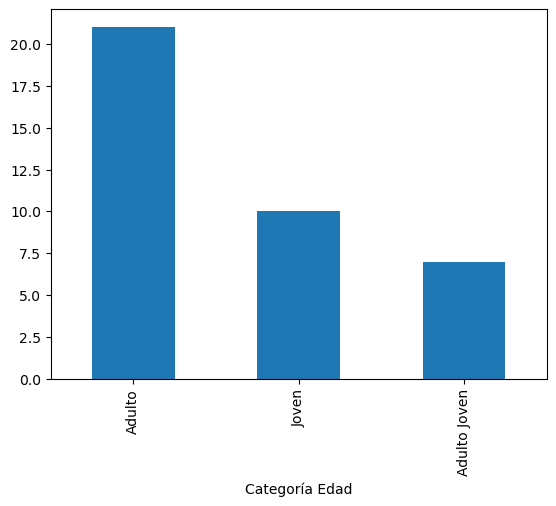

In [14]:
df['Categoría Edad'].value_counts().plot.bar()

<Axes: ylabel='Categoría Edad'>

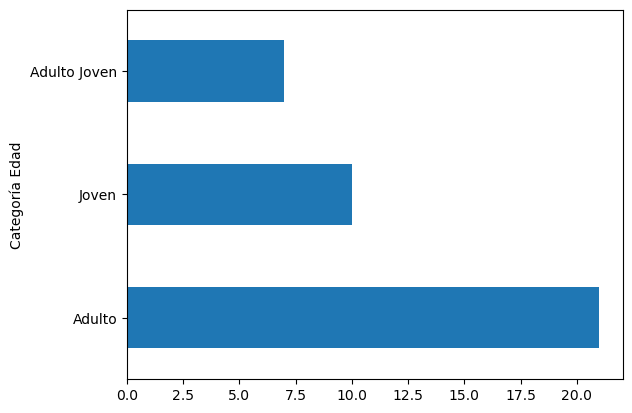

In [15]:
df['Categoría Edad'].value_counts().plot.barh()

### 7 Funciones que dependen de más de una columna

In [16]:
# Definimos la función que aplica el criterio a cada fila
def evaluar_alumno(fila):
    # Accedemos a las notas de la fila usando los nombres de las columnas
    nota1 = fila['Nota 1']
    nota2 = fila['Nota 2']

    # Aplicamos el criterio: ambas notas deben ser 70 o más para aprobar
    if nota1 >= 7 and nota2 >= 7:
        return 'Aprobado'
    else:
        return 'Reprobado'

df_test = df.copy()

# print(print(df_test.info()))
df_test['Estado'] = df.apply(evaluar_alumno, axis=1)

df_test

,Estudiante,Edad,Nota 1,Nota 2,Promedio,Categoría Edad,Estado
0,Acosta Camila,38,9,5,7.0,Adulto,Reprobado
1,Aguirre Teo,58,5,1,3.0,Adulto,Reprobado
2,Ayala Jazmín,19,8,9,8.5,Joven,Aprobado
3,Benítez Facundo,60,6,7,6.5,Adulto,Reprobado
4,Bustos Mateo,38,9,0,4.5,Adulto,Reprobado
5,Castro Micaela,24,10,10,10.0,Joven,Aprobado
6,Correa Thiago,34,7,2,4.5,Adulto,Reprobado
7,Díaz Sofía,47,8,8,8.0,Adulto,Aprobado
8,Fernández Pedro,43,7,3,5.0,Adulto,Reprobado
9,Figueroa Victoria,26,9,6,7.5,Adulto Joven,Reprobado


In [17]:
df_test.loc[5]

Estudiante        Castro Micaela
Edad                          24
Nota 1                        10
Nota 2                        10
Promedio                    10.0
Categoría Edad             Joven
Estado                  Aprobado
Name: 5, dtype: object

### 8. Insertar una columna en en un lugar arbitrario. 

Supongamos que queremos una nueva columna, a la derecha de "Nota 2", que se llame "Nota 3". Podemo usar
`df.insert(loc=posicion_de_insercion, column=nombre_nueva_columna, value=valores_nueva_columna)`




In [18]:
# creamos la columna y guardamos en una variable apropiada


nota_3 = [7, 2, 9, 0, 5, 10, 1, 8, 3, 6, 4, 9, 2, 7, 0, 5, 10, 1, 8, 3, 6, 4, 9, 2, 7, 0, 5, 10, 1, 8, 3, 6, 4, 9, 2, 7, 0, 5]

# obtenemos la posición de la columna "Nota 2" (aunque es obvio en este DataFrame pequeño, lo hacemos formal)

posicion = df.columns.get_loc('Nota 2')

print (posicion)

3


In [19]:
df.insert(loc = 4, column = 'Nota 3', value = nota_3)

df

,Estudiante,Edad,Nota 1,Nota 2,Nota 3,Promedio,Categoría Edad
0,Acosta Camila,38,9,5,7,7.0,Adulto
1,Aguirre Teo,58,5,1,2,3.0,Adulto
2,Ayala Jazmín,19,8,9,9,8.5,Joven
3,Benítez Facundo,60,6,7,0,6.5,Adulto
4,Bustos Mateo,38,9,0,5,4.5,Adulto
5,Castro Micaela,24,10,10,10,10.0,Joven
6,Correa Thiago,34,7,2,1,4.5,Adulto
7,Díaz Sofía,47,8,8,8,8.0,Adulto
8,Fernández Pedro,43,7,3,3,5.0,Adulto
9,Figueroa Victoria,26,9,6,6,7.5,Adulto Joven


## 9. Manipulación de celdas

### 9.1 En la manipulación de celdas se suele usar el método `.loc`.

La Sintaxis Básica de `.loc`
La forma general es: `df.loc[selector_de_filas, selector_de_columnas]`

*SELECCIÓN BASADA EN ETIQUETAS (ojo, si nuestro df tienen un index numérico, esos números serán sus etiquetas)*

selector_de_filas: Le decimos qué filas queremos.

selector_de_columnas: Le decís qué columnas queremos (¡opcional, si no se pone nada, trae todas las columnas!).

### 9.2 También existe `.iloc`.

La Sintaxis Básica de `.iloc`
La forma general es: `df.iloc[selector_de_filas, selector_de_columnas]`

*SELECCIÓN BASADA EN ÍNDICES*

Algunos ejemplos

Un número entero simple: Para seleccionar una única fila o columna por su posición.

`df.iloc[0]` -> Selecciona la primera fila.

`df.iloc[:, 1]` -> Selecciona la segunda columna (todas las filas, segunda columna).

`df.iloc[2, 0]` -> Selecciona el valor en la tercera fila (posición 2) y la primera columna (posición 0).

Una lista de números enteros: Para seleccionar múltiples filas o columnas no consecutivas por sus posiciones.

`df.iloc[[0, 2, 5]]` -> Selecciona la primera, tercera y sexta fila.

`df.iloc[:, [0, 2]]` -> Selecciona la primera y tercera columna (todas las filas).

`df.iloc[[1, 3], [0, 2]]` -> Selecciona valores de la segunda y cuarta fila, y la primera y tercera columna.


In [20]:
# Acceder a una celda en particular
# Supongamos que queremos ver la 'Nota 1' del alumno en el índice 0 (el primero)
print("Nota 1 del alumno en el índice 0:", df.loc[0, 'Nota 1'], '\n')

# Si queremos acceder a un estudiante por su nombre, usamos un FILTRO
print(df[df['Estudiante'] == 'Castro Micaela'], '\n')

# Si queremos acceder a su índice
print(df[df['Estudiante'] == 'Castro Micaela'].index, '\n')


# Si queremos ver sólo estas columnas para la estudiante
filtro = (df['Estudiante'] == 'Castro Micaela')

print(df.loc[filtro, ['Estudiante', 'Nota 1']])

Nota 1 del alumno en el índice 0: 9 

       Estudiante  Edad  Nota 1  Nota 2  Nota 3  Promedio Categoría Edad
5  Castro Micaela    24      10      10      10      10.0          Joven 

Index([5], dtype='int64') 

       Estudiante  Nota 1
5  Castro Micaela      10


### 10. Versión simple de apply: mapeo 

#### Usamos map cuando:

1. Trabajamos sobre una sola columna
2. Hacemos transformasiones _simples_ de los elementos de esa columna (.apply puede ser más poderoso que .map)

#### Una transformación simple por excelencia es _mapear_ valores exactos como se muestra en la celda debajo

In [21]:
# + Definir el diccionario de mapeo. Solo funciona para valores EXACTOS

mapeo_nota1 = {
    6.0: 'rasposo',
    10.0: 'sobresaliente'
}

# + Aplicar el mapeo a la columna 'Promedio' para crear la nueva columna
df['Clasificación Nota 1'] = df['Nota 1'].map(mapeo_nota1)

print(df.columns)

df

Index(['Estudiante', 'Edad', 'Nota 1', 'Nota 2', 'Nota 3', 'Promedio',
       'Categoría Edad', 'Clasificación Nota 1'],
      dtype='object')


,Estudiante,Edad,Nota 1,Nota 2,Nota 3,Promedio,Categoría Edad,Clasificación Nota 1
0,Acosta Camila,38,9,5,7,7.0,Adulto,NaN
1,Aguirre Teo,58,5,1,2,3.0,Adulto,NaN
2,Ayala Jazmín,19,8,9,9,8.5,Joven,NaN
3,Benítez Facundo,60,6,7,0,6.5,Adulto,rasposo
4,Bustos Mateo,38,9,0,5,4.5,Adulto,NaN
5,Castro Micaela,24,10,10,10,10.0,Joven,sobresaliente
6,Correa Thiago,34,7,2,1,4.5,Adulto,NaN
7,Díaz Sofía,47,8,8,8,8.0,Adulto,NaN
8,Fernández Pedro,43,7,3,3,5.0,Adulto,NaN
9,Figueroa Victoria,26,9,6,6,7.5,Adulto Joven,NaN


### 11.  Crear una columna nueva que requiera hacer un pd.cut

¿Cómo funciona?

Imaginemos que pd.cut es un clasificador automático superinteligente:

Le damos la columna numérica: "Che, pd.cut, acá tenés todos los Promedio de mis alumnos."

 Le decimos dónde "cortar" (los bins): "Quiero que los cortes cada 4 puntos, después en 7 y al final en 10. ¡Esos son mis límites!"

Y le decimos cómo llamar a cada cajón (los labels): "Al primer cajón le pones 'Insuficiente', al siguiente 'Regular', y así sucesivamente."

¡Y listo! pd.cut recorre cada número en tu columna, ve en qué "cajón" o "rango" cae, y le asigna la etiqueta correspondiente. El resultado es una nueva columna categórica que permite entender mucho mejor dónde se agrupan tus datos.

In [22]:
# + Definir los bins (intervalos) y las etiquetas para las categorías de Promedio
# Podemos usar los mismos bins que usaste para Calificación o definir nuevos para Promedio
bins_promedio = [0, 4, 7, 10] # Ejemplo: [0,4) Reprobado, [4,7) Regular, [7,10] Sobresaliente
labels_desempeno = ['Insuficiente', 'Regular', 'Sobresaliente']

# + Aplicar pd.cut a la columna 'Promedio'
# Observa que 'right=False' significa que el intervalo es [inicio, fin) excepto el último [inicio, fin]
df['Nivel Desempeño'] = pd.cut(df['Promedio'],
                                bins=bins_promedio,
                                labels=labels_desempeno,
                                right=False) # [0, 4), [4, 7), [7, 10]

print("\n--- DataFrame (temporal porque no lo guardamos en ninguna variable) con la nueva columna 'Nivel Desempeño' ---\n")

# Hacemos un print del sub-DataFrame que queremos
print(df[['Estudiante', 'Promedio', 'Nivel Desempeño']].head())



--- DataFrame (temporal porque no lo guardamos en ninguna variable) con la nueva columna 'Nivel Desempeño' ---

        Estudiante  Promedio Nivel Desempeño
0    Acosta Camila       7.0   Sobresaliente
1      Aguirre Teo       3.0    Insuficiente
2     Ayala Jazmín       8.5   Sobresaliente
3  Benítez Facundo       6.5         Regular
4     Bustos Mateo       4.5         Regular


### 12. Realizar una operacion sobre un subconjunto de filas (filtro).

Vamos a crear una nueva columna llamada 'Promedio con Bonus'. Para los estudiantes que tengan una Edad menor o igual a 21 años, a su Promedio le sumaremos 0.5 puntos extra. Para el resto de los estudiantes, esta nueva columna simplemente será igual a su Promedio original.

In [23]:
# 1. Creamos la nueva columna y la inicializamos con el 'Promedio' original
# De esta forma, los que no cumplan el filtro mantendrán su promedio normal.
df['Promedio con Bonus'] = df['Promedio']

# 2. Creamos nuestro filtro: Estudiantes con Edad <= 21
filtro_jovenes = df['Edad'] <= 21

# 3. Aplicamos la operación *solo* a las filas que cumplen el filtro
# Usamos .loc para seleccionar las filas filtradas y la columna 'Promedio con Bonus'
# Y luego asignamos el resultado de la operación.
df.loc[filtro_jovenes, 'Promedio con Bonus'] = df['Promedio'] + 0.5

# 4. Mostramos el DataFrame con la nueva columna para ver el resultado
print("\n--- DataFrame con 'Promedio con Bonus' (aplicado a jóvenes) ---\n")
print(df[['Estudiante', 'Edad', 'Promedio', 'Promedio con Bonus']])



--- DataFrame con 'Promedio con Bonus' (aplicado a jóvenes) ---

           Estudiante  Edad  Promedio  Promedio con Bonus
0       Acosta Camila    38       7.0                 7.0
1         Aguirre Teo    58       3.0                 3.0
2        Ayala Jazmín    19       8.5                 9.0
3     Benítez Facundo    60       6.5                 6.5
4        Bustos Mateo    38       4.5                 4.5
5      Castro Micaela    24      10.0                10.0
6       Correa Thiago    34       4.5                 4.5
7          Díaz Sofía    47       8.0                 8.0
8     Fernández Pedro    43       5.0                 5.0
9   Figueroa Victoria    26       7.5                 7.5
10   Flores Valentina    40       3.0                 3.0
11   García Florencia    56       7.5                 7.5
12   Giménez Josefina    29       4.0                 4.0
13      Godoy Emanuel    38       6.0                 6.0
14          Gómez Ana    22       7.5                 7.5
15   H

# Sección Plots

<Axes: title={'center': 'Distribución Edad - Promedio'}, xlabel='Edad', ylabel='Promedio'>

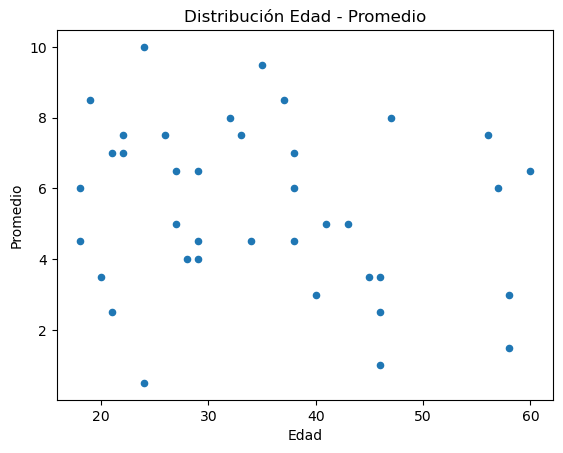

In [24]:
# Supongamos que quiero hacer un scatterplot para ver si existe algún patrón en la distribución de las notas acorde a la Edad. Easy, aplicamos el método plot y luego scatter (En clase vimos el concepto de método en Pandas).

df.plot.scatter(x = "Edad", y = "Promedio", title = "Distribución Edad - Promedio")

<Axes: title={'center': 'Promedio'}, xlabel='Categoría Edad'>

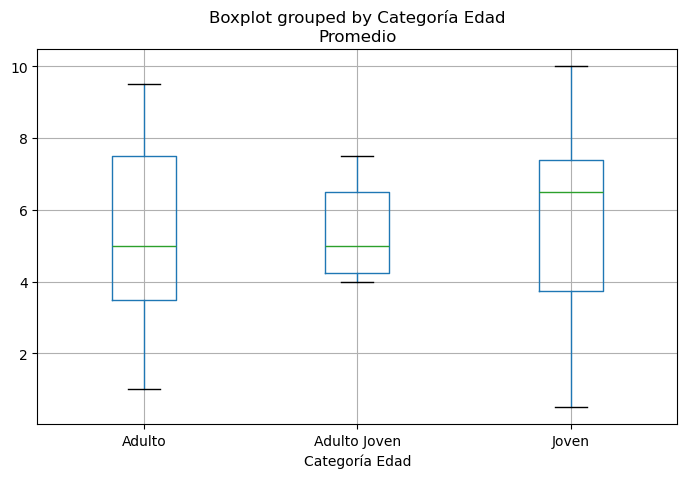

In [25]:
df.boxplot(column='Promedio', by='Categoría Edad', figsize=(8, 5))

Un **boxplot** (o diagrama de caja y bigotes) es una herramienta visual poderosa para entender la **distribución de un conjunto de datos numéricos** y para comparar distribuciones entre diferentes grupos. Divide los datos en cuartiles, ofreciéndote un resumen rápido de su dispersión y tendencia central.

### **Las Partes de un Boxplot**

Un boxplot típico consta de cinco elementos principales, conocidos como los "cinco números resumen":

+   **La Caja (Box):**
    +   **Línea Central (Mediana / Segundo Cuartil - Q2):** La línea que está dentro de la caja (generalmente la más gruesa) representa la **mediana** de los datos. Es el valor central que divide el conjunto de datos en dos mitades iguales (el 50% de los datos están por debajo y el 50% por encima).
    +   **Borde Inferior de la Caja (Primer Cuartil - Q1):** Representa el **25º percentil**. Esto significa que el 25% de los datos se encuentran por debajo de este valor.
    +   **Borde Superior de la Caja (Tercer Cuartil - Q3):** Representa el **75º percentil**. Esto significa que el 75% de los datos se encuentran por debajo de este valor.
    +   **Longitud de la Caja (Rango Intercuartílico - IQR):** La longitud de la caja (Q3 - Q1) es el **Rango Intercuartílico (IQR)**. Representa el 50% central de los datos. Una caja más corta indica que los datos están más concentrados, una más larga sugiere mayor dispersión.

+   **Los Bigotes (Whiskers):**
    +   Las líneas que se extienden desde la caja representan el rango de los datos que **no se consideran valores atípicos**.
    +   Generalmente, se extienden hasta el último dato que no supera $1.5 \times \text{IQR}$ por encima de Q3 o por debajo de Q1.

+   **Valores Atípicos (Outliers):**
    +   Los puntos individuales que se encuentran más allá de los bigotes.
    +   Indican observaciones que se desvían significativamente del resto de los datos y merecen una investigación más profunda.

### **Qué Información Obtienes de un Boxplot**

Al observar un boxplot, puedes extraer varias conclusiones importantes sobre tu distribución:

+   **Tendencia Central:** La **mediana** te da una idea del valor "típico" de los datos.
+   **Dispersión o Variabilidad:**
    +   La **longitud de la caja (IQR)** te dice qué tan dispersos están el 50% central de los datos.
    +   La **longitud total de los bigotes** te da una idea del rango general de los datos (sin atípicos).
+   **Simetría de la Distribución:**
    +   Si la mediana está en el centro de la caja y los bigotes son de longitud similar, la distribución es probablemente **simétrica**.
    +   Si la mediana está más cerca de un extremo de la caja o un bigote es mucho más largo, la distribución es **asimétrica** (sesgada).

Cuando tienes múltiples boxplots (uno por cada categoría o grupo), puedes compararlos visualmente:

+   **Comparar Medias/Medianas:** Observa dónde se ubican las líneas de la mediana en cada caja.
+   **Comparar Dispersión:** Compara la longitud de las cajas y los bigotes entre los grupos.
+   **Comparar Simetría:** Observa si las distribuciones son simétricas o sesgadas de manera diferente.
+   **Comparar Valores Atípicos:** Identifica si algún grupo tiene más o menos valores atípicos, o si son más extremos.

#### Conjunto de datos donde intencionalmente incluyas un valor extremo para verlo en acción:

DataFrame de ejemplo con posibles atípicos:
       Categoria  Notas
0          joven    7.5
1   adulto joven    8.0
2         adulto    6.5
3          joven    9.0
4         adulto    7.0
5   adulto joven    8.5
6          joven    6.0
7         adulto    9.5
8   adulto joven    7.8
9          joven    8.2
10         joven    7.0
11  adulto joven    8.1
12        adulto    6.8
13         joven    9.1
14        adulto    7.2
15  adulto joven    8.3
16         joven    6.2
17        adulto    9.3
18  adulto joven    7.9
19         joven    8.0
20        adulto    2.0
21         joven    1.0


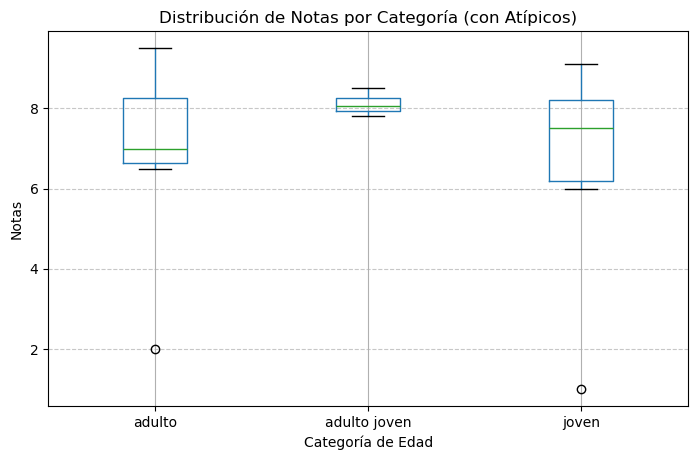

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear un DataFrame de ejemplo con un VALOR ATÍPICO CLARO
data = {
    'Categoria': ['joven', 'adulto joven', 'adulto', 'joven', 'adulto', 'adulto joven', 'joven', 'adulto', 'adulto joven', 'joven',
                  'joven', 'adulto joven', 'adulto', 'joven', 'adulto', 'adulto joven', 'joven', 'adulto', 'adulto joven', 'joven'],
    'Notas': [7.5, 8.0, 6.5, 9.0, 7.0, 8.5, 6.0, 9.5, 7.8, 8.2,
              7.0, 8.1, 6.8, 9.1, 7.2, 8.3, 6.2, 9.3, 7.9, 8.0]
}
df = pd.DataFrame(data)

# Añadir una nota muy baja que será un atípico en la categoría 'adulto'
df.loc[len(df)] = {'Categoria': 'adulto', 'Notas': 2.0}
# Añadir una nota muy alta que será un atípico en la categoría 'joven'
df.loc[len(df)] = {'Categoria': 'joven', 'Notas': 1.0} # Cambiado a 1.0 para asegurar que sea atípico

print("DataFrame de ejemplo con posibles atípicos:")
print(df)

# Crear el boxplot "Pandas-style"
ax = df.boxplot(column='Notas', by='Categoria', figsize=(8, 5))

plt.title('Distribución de Notas por Categoría (con Atípicos)')
plt.suptitle('') # Suprimir el título automático
plt.xlabel('Categoría de Edad')
plt.ylabel('Notas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()